In [89]:
import pandas as pd
import numpy as np
from IPython.display import display

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    silhouette_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score
)
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment
from scipy.spatial import ConvexHull
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

import warnings
warnings.filterwarnings('ignore')

In [90]:
# =========================================================================
# DATEN LADEN: CSV statt .ld-Rohdateien
# =========================================================================
df_raw = pd.read_csv("driver_features_combined.csv")

# Fahrer-ID bereinigen (fuehrende/folgende Unterstriche entfernen)
df_raw['Fahrer_ID'] = df_raw['driver_id'].str.strip('_')

print(f"[Info] CSV geladen: {df_raw.shape[0]} Segmente, {df_raw['Fahrer_ID'].nunique()} Fahrer")
print(f"[Info] Fahrer: {sorted(df_raw['Fahrer_ID'].unique())}")
print(f"[Info] Spalten gesamt: {df_raw.shape[1]}")

# Segment-Typ-Flags (Streckenkontext) und Metadaten aus Feature-Matrix ausschliessen:
# Diese beschreiben WO auf der Strecke, nicht WIE der Fahrer faehrt.
meta_cols = ['driver_id', 'Fahrer_ID', 'segment_id',
             'is_straight', 'is_eingang', 'is_mitte', 'is_apex']

feature_cols = [c for c in df_raw.columns if c not in meta_cols]
print(f"[Info] {len(feature_cols)} Features fuer das Clustering verfuegbar")

df_master_ml = df_raw.copy()
display(df_master_ml[['Fahrer_ID'] + feature_cols[:8]].head())

[Info] CSV geladen: 2472 Segmente, 25 Fahrer
[Info] Fahrer: ['ALAD201', 'ANIC011', 'BRIG160', 'CHKA302', 'FARC062', 'FEFH030', 'FIND031', 'ISMS130', 'JADR090', 'JOI033', 'JORC051', 'KEPD180', 'KETZ160', 'LIAZ070', 'MAKR091', 'MIBE102', 'NIDL241', 'NIMB230', 'OLOT290', 'RINE150', 'SEMD260', 'SHMM240', 'SOMD122', 'THTH312', 'TOMS241']
[Info] Spalten gesamt: 131
[Info] 124 Features fuer das Clustering verfuegbar


,Fahrer_ID,v_car_mean,v_car_std,v_car_min,v_car_max,v_car_skew,v_car_kurtosis,percent_throttle_mean,percent_throttle_std
0,ALAD201,69.751500,34.126573,5.826667,134.170000,0.420380,-0.839565,50.28945,29.433977
1,ALAD201,35.881367,26.002067,0.000000,109.973333,0.182828,-0.753572,41.41992,31.805968
2,ALAD201,38.570853,29.908215,0.000000,100.753333,0.371609,-0.898940,39.97920,23.637897
3,ALAD201,41.020873,33.594348,0.000000,100.753333,0.147853,-1.283912,23.29376,22.186999
4,ALAD201,23.897313,24.840225,0.000000,93.573333,1.141907,0.679014,17.22238,20.972144


In [91]:
# =========================================================================
# DATEN-BEREINIGUNG: IQR-basierte Ausreisser-Filterung pro Fahrer
# =========================================================================
print(f"[Data-Cleaning] Datensatz VOR der Bereinigung: {df_master_ml.shape[0]} Zeilen")
df_vorher = df_master_ml.copy()
bereinigte_fahrer_dfs = []

# Kern-Features fuer Ausreisser-Erkennung
# (Bremsstreuung, Gasstreuung, Geschwindigkeitsstreuung)
fokus_features = [
    'percent_brake_std',
    'percent_throttle_std',
    'v_car_std',
]

for fahrer_id, fahrer_gruppe in df_master_ml.groupby('Fahrer_ID'):
    for col in fokus_features:
        if col in fahrer_gruppe.columns:
            Q1 = fahrer_gruppe[col].quantile(0.25)
            Q3 = fahrer_gruppe[col].quantile(0.75)
            IQR = Q3 - Q1
            untere_grenze = Q1 - 1.5 * IQR
            obere_grenze  = Q3 + 1.5 * IQR
            fahrer_gruppe = fahrer_gruppe[
                (fahrer_gruppe[col] >= untere_grenze) &
                (fahrer_gruppe[col] <= obere_grenze)
            ]
    bereinigte_fahrer_dfs.append(fahrer_gruppe)

df_master_ml = pd.concat(bereinigte_fahrer_dfs, ignore_index=True)

entfernte = df_vorher.shape[0] - df_master_ml.shape[0]
print(f"[Data-Cleaning] Datensatz NACH der Bereinigung: {df_master_ml.shape[0]} Zeilen")
print(f"[Data-Cleaning] Erfolg! {entfernte} Ausreisser-Segmente eliminiert.")

[Data-Cleaning] Datensatz VOR der Bereinigung: 2472 Zeilen
[Data-Cleaning] Datensatz NACH der Bereinigung: 2275 Zeilen
[Data-Cleaning] Erfolg! 197 Ausreisser-Segmente eliminiert.


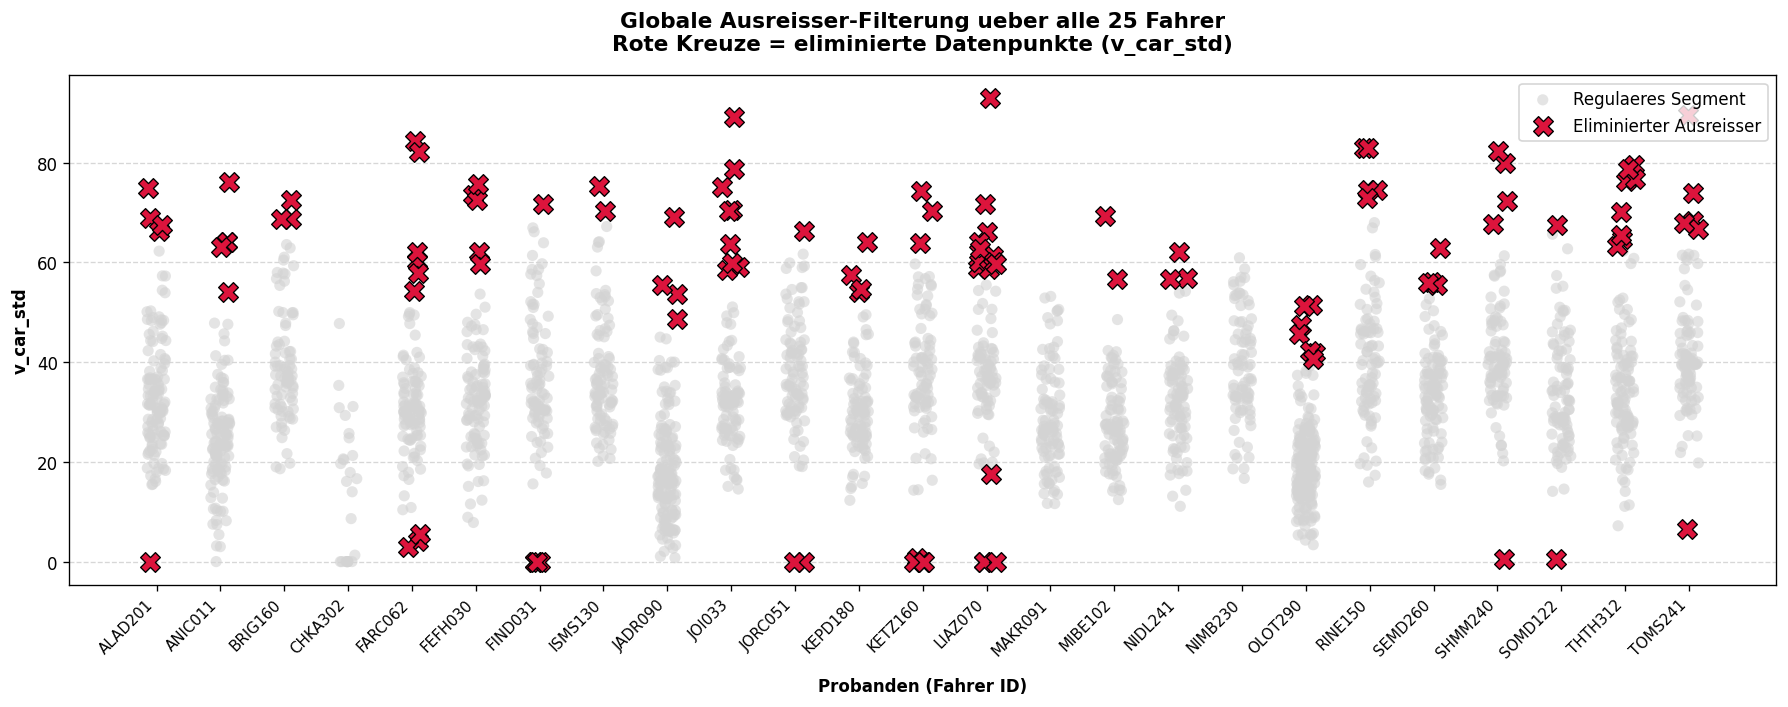

In [92]:
# =========================================================================
# VISUALISIERUNG: Globale Ausreisser-Darstellung
# =========================================================================
feature_viz = 'v_car_std'

df_global_plot = df_vorher.copy()
df_global_plot['Is_Outlier'] = False
df_global_plot['Fahrer_ID'] = df_global_plot['driver_id'].str.strip('_')

for fahrer_id, fahrer_gruppe in df_global_plot.groupby('Fahrer_ID'):
    if feature_viz in fahrer_gruppe.columns:
        Q1 = fahrer_gruppe[feature_viz].quantile(0.25)
        Q3 = fahrer_gruppe[feature_viz].quantile(0.75)
        IQR = Q3 - Q1
        outlier_mask = (
            (fahrer_gruppe[feature_viz] < Q1 - 1.5 * IQR) |
            (fahrer_gruppe[feature_viz] > Q3 + 1.5 * IQR)
        )
        df_global_plot.loc[fahrer_gruppe[outlier_mask].index, 'Is_Outlier'] = True

unique_drivers = sorted(df_global_plot['Fahrer_ID'].unique())
driver_to_idx  = {d: i for i, d in enumerate(unique_drivers)}
df_global_plot['Fahrer_Idx'] = df_global_plot['Fahrer_ID'].map(driver_to_idx)

np.random.seed(42)
df_global_plot['X_Jittered'] = (
    df_global_plot['Fahrer_Idx'] +
    np.random.uniform(-0.15, 0.15, len(df_global_plot))
)

fig, ax = plt.subplots(figsize=(15, 6), dpi=120)
normal_data  = df_global_plot[~df_global_plot['Is_Outlier']]
outlier_data = df_global_plot[df_global_plot['Is_Outlier']]

ax.scatter(normal_data['X_Jittered'], normal_data[feature_viz],
           color='lightgray', alpha=0.6, s=45, label='Regulaeres Segment',
           edgecolors='none', zorder=2)
ax.scatter(outlier_data['X_Jittered'], outlier_data[feature_viz],
           color='crimson', marker='X', s=140, label='Eliminierter Ausreisser',
           edgecolors='black', linewidths=0.8, zorder=5)

ax.set_title(
    f"Globale Ausreisser-Filterung ueber alle {len(unique_drivers)} Fahrer\n"
    f"Rote Kreuze = eliminierte Datenpunkte ({feature_viz})",
    fontweight='bold', fontsize=13, pad=15
)
ax.set_xlabel("Probanden (Fahrer ID)", fontweight='bold', labelpad=10)
ax.set_ylabel(feature_viz, fontweight='bold')
ax.set_xticks(range(len(unique_drivers)))
ax.set_xticklabels(unique_drivers, rotation=45, ha='right', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig("hebel1_global_outlier_plot.png", bbox_inches='tight', dpi=300)
plt.show()


--- PCA VARIANZ-REPORT ---
PC1: erklaert 24.6% der Fahrer-Unterschiede
PC2: erklaert 11.0% der Fahrer-Unterschiede
PC3: erklaert 6.3% der Fahrer-Unterschiede
-> Gesamt im 3D-Raum: 41.9%
-----------------------------------


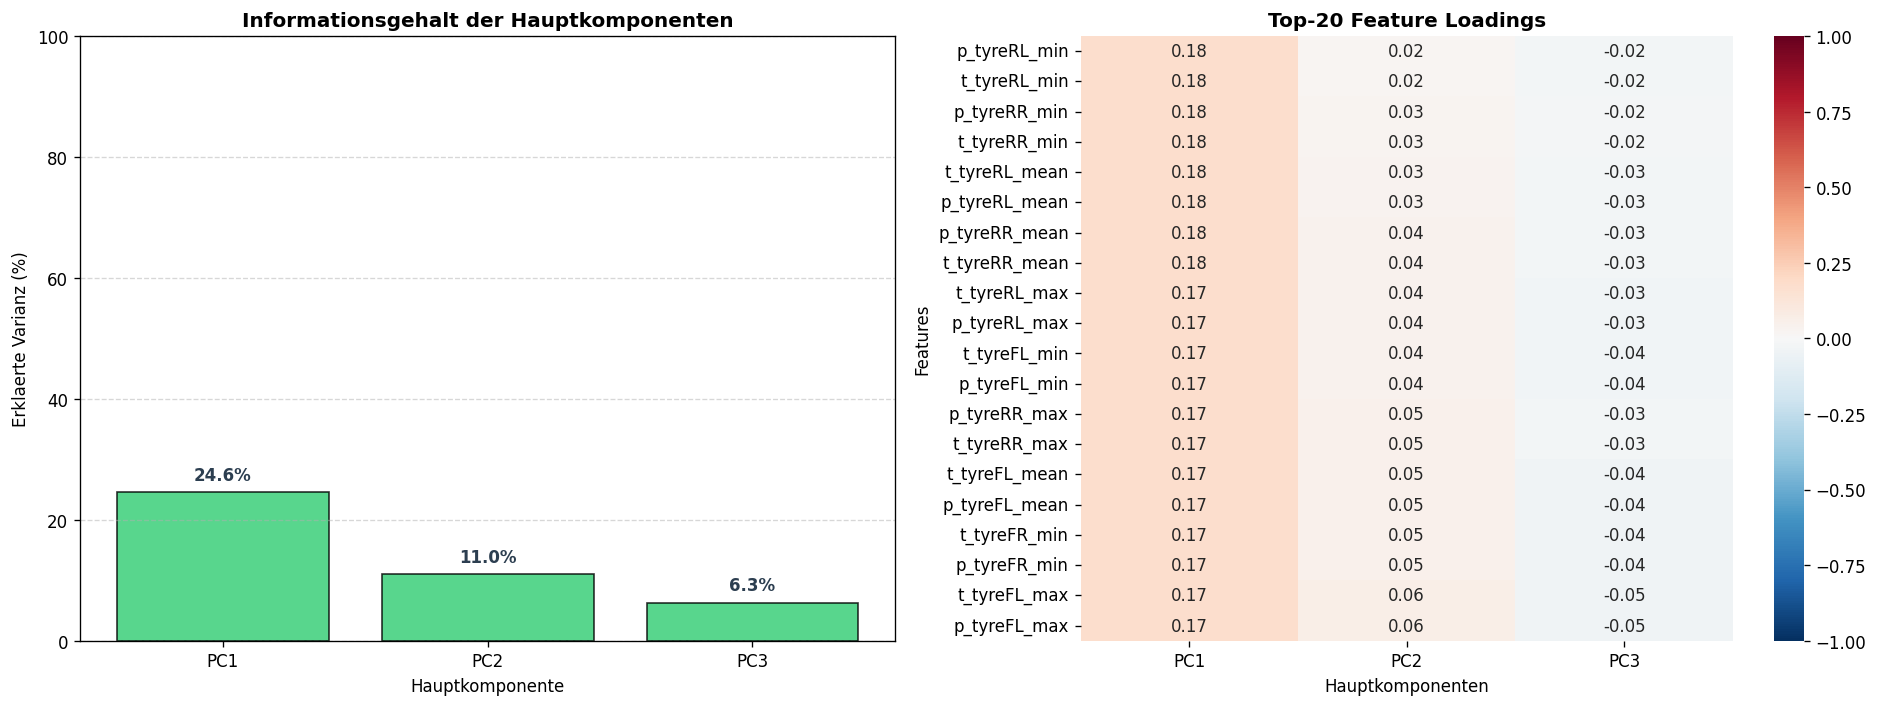

In [93]:
# =========================================================================
# PCA-VARIANZ-ANALYSE
# =========================================================================
X_pca_input = df_master_ml[feature_cols]
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_pca_input)

pca = PCA(n_components=3)
pca.fit_transform(X_scaled_pca)
var_exp = pca.explained_variance_ratio_

print("\n--- PCA VARIANZ-REPORT ---")
for idx, anteil in enumerate(var_exp):
    print(f"PC{idx+1}: erklaert {anteil*100:.1f}% der Fahrer-Unterschiede")
print(f"-> Gesamt im 3D-Raum: {sum(var_exp)*100:.1f}%")
print("-" * 35)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

bars = ax1.bar(
    [f"PC{i+1}" for i in range(3)], var_exp * 100,
    color='#2ecc71', edgecolor='k', alpha=0.8
)
ax1.set_title("Informationsgehalt der Hauptkomponenten", fontweight='bold', fontsize=12)
ax1.set_xlabel("Hauptkomponente")
ax1.set_ylabel("Erklaerte Varianz (%)")
ax1.set_ylim(0, 100)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2., h + 2,
             f"{h:.1f}%", ha='center', fontweight='bold', color='#2c3e50')

# Top-20 Feature Loadings der ersten Hauptkomponente
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=feature_cols
)
top_features = loadings_df['PC1'].abs().nlargest(20).index
sns.heatmap(
    loadings_df.loc[top_features], annot=True,
    cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f", ax=ax2
)
ax2.set_title("Top-20 Feature Loadings", fontweight='bold', fontsize=12)
ax2.set_ylabel("Features")
ax2.set_xlabel("Hauptkomponenten")
plt.tight_layout()
plt.show()

[1/2] Trainiere K-Means (Baseline)...
[2/2] Trainiere Gaussian Mixture Model...

Metrik                              K-Means          GMM
-------------------------------------------------------
Silhouette Score                      0.080        0.075
Training Accuracy                     27.6%        26.4%
GMM BIC Score                            --     207940.6


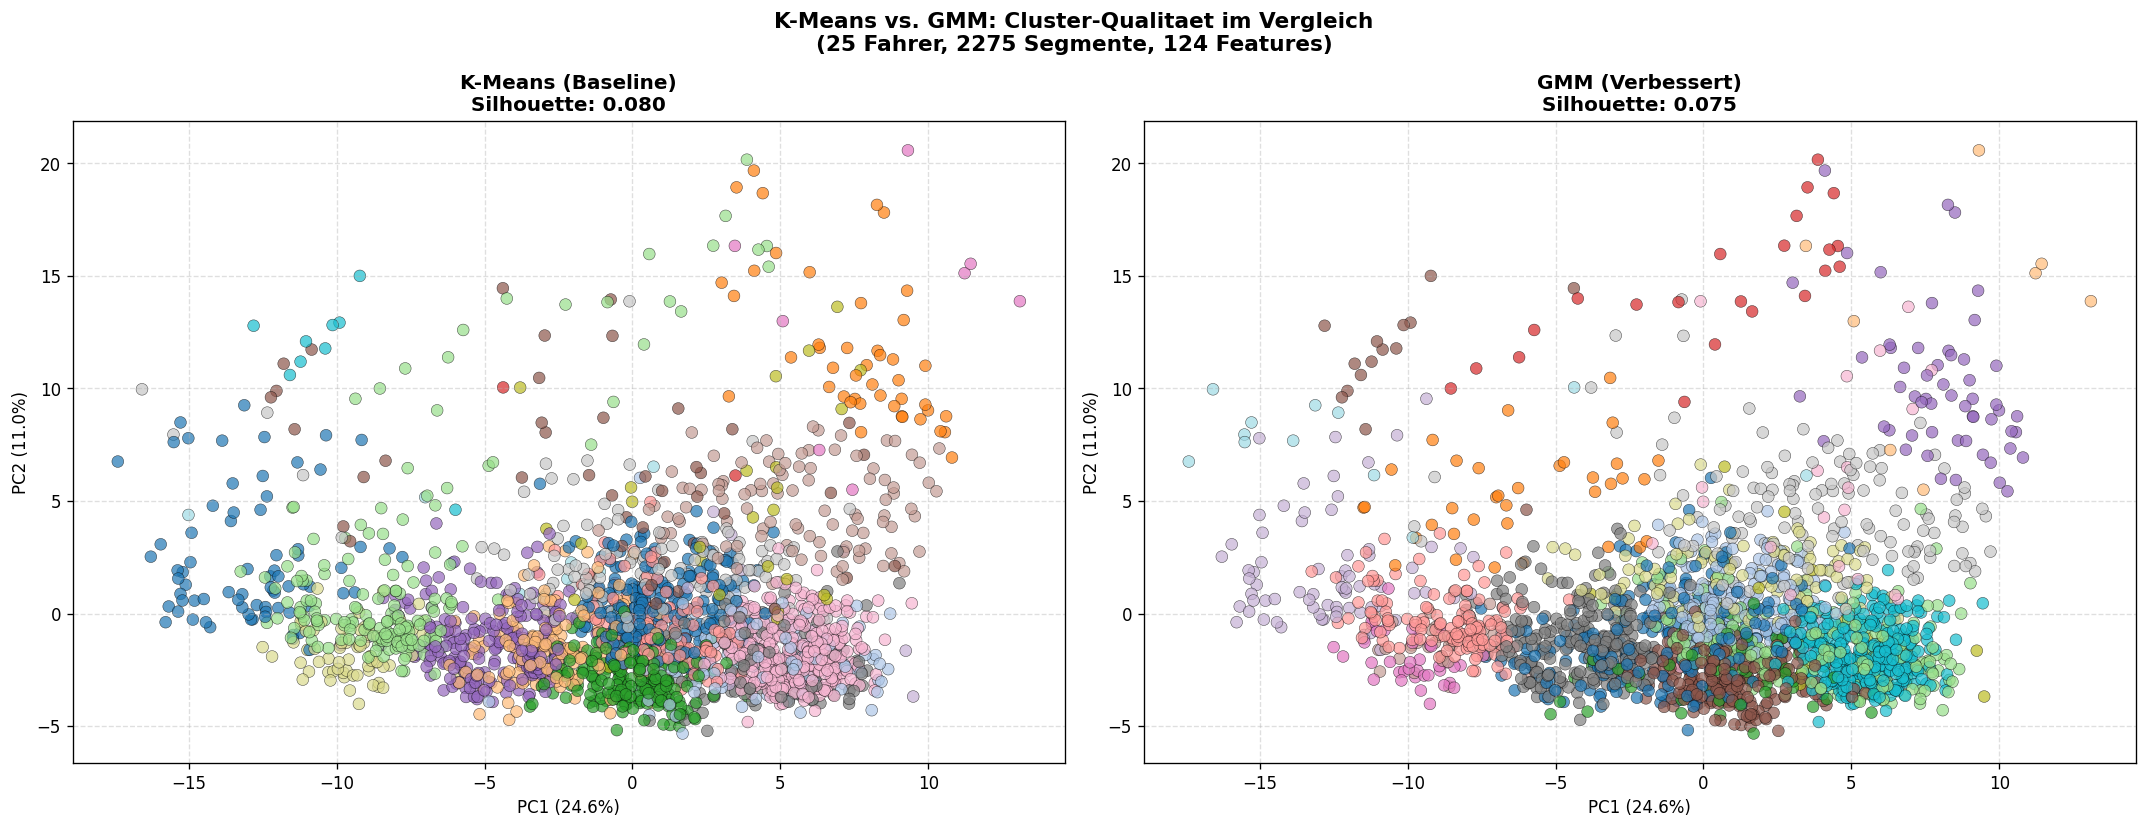

In [94]:
# =========================================================================
# MODELL-VERGLEICH: K-Means (Baseline) vs. GMM (Verbessert)
# =========================================================================
#
# Warum GMM besser ist als K-Means:
#   K-Means geht von kugelfoermigen Clustern aus (euklidische Distanz).
#   Fahrprofile sind aber keine Kugeln -- sie haben unterschiedliche
#   Ausdehnungen und Korrelationen. Das Gaussian Mixture Model (GMM)
#   modelliert jeden Fahrer als multivariate Normalverteilung mit eigener
#   Kovarianzmatrix ('full') und erlaubt ellipsoide Cluster beliebiger
#   Orientierung. Ausserdem nutzen wir jetzt alle ~120 CSV-Features
#   statt nur 8 handberechneter Aggregate.
# =========================================================================

X_clustering = df_master_ml[feature_cols]
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X_clustering)
num_drivers = df_master_ml['Fahrer_ID'].nunique()

# --- K-Means (Baseline) ---
print("[1/2] Trainiere K-Means (Baseline)...")
kmeans_full = KMeans(n_clusters=num_drivers, random_state=42, n_init=100)
df_master_ml['KMeans_Cluster'] = kmeans_full.fit_predict(X_scaled)

# --- GMM (Verbessertes Modell) ---
print("[2/2] Trainiere Gaussian Mixture Model...")
gmm_full = GaussianMixture(
    n_components=num_drivers, covariance_type='full',
    n_init=10, max_iter=500, random_state=42
)
df_master_ml['GMM_Cluster'] = gmm_full.fit_predict(X_scaled)

# Hungarian Matching fuer beide Modelle
def hungarian_match(df, cluster_col, true_col):
    contingency = pd.crosstab(df[true_col], df[cluster_col])
    f_idx, c_idx = linear_sum_assignment(-contingency.values)
    return {contingency.columns[c]: contingency.index[f]
            for f, c in zip(f_idx, c_idx)}

kmeans_map = hungarian_match(df_master_ml, 'KMeans_Cluster', 'Fahrer_ID')
gmm_map    = hungarian_match(df_master_ml, 'GMM_Cluster',    'Fahrer_ID')

df_master_ml['KMeans_Fahrer'] = df_master_ml['KMeans_Cluster'].map(kmeans_map)
df_master_ml['GMM_Fahrer']    = df_master_ml['GMM_Cluster'].map(gmm_map)

km_sil  = silhouette_score(X_scaled, df_master_ml['KMeans_Cluster'])
gmm_sil = silhouette_score(X_scaled, df_master_ml['GMM_Cluster'])
km_acc  = accuracy_score(df_master_ml['Fahrer_ID'], df_master_ml['KMeans_Fahrer'])
gmm_acc = accuracy_score(df_master_ml['Fahrer_ID'], df_master_ml['GMM_Fahrer'])

print(f"\n{'Metrik':<30} {'K-Means':>12} {'GMM':>12}")
print("-" * 55)
print(f"{'Silhouette Score':<30} {km_sil:>12.3f} {gmm_sil:>12.3f}")
print(f"{'Training Accuracy':<30} {km_acc:>12.1%} {gmm_acc:>12.1%}")
print(f"{'GMM BIC Score':<30} {'--':>12} {gmm_full.bic(X_scaled):>12.1f}")

# PCA-Visualisierung K-Means vs. GMM
pca_viz = PCA(n_components=2)
X_pca_2d = pca_viz.fit_transform(X_scaled)
var_v = pca_viz.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=120)
for ax, (model_name, col, sil) in zip(
    axes,
    [('K-Means (Baseline)', 'KMeans_Cluster', km_sil),
     ('GMM (Verbessert)',   'GMM_Cluster',    gmm_sil)]
):
    ax.scatter(
        X_pca_2d[:, 0], X_pca_2d[:, 1],
        c=df_master_ml[col], cmap='tab20',
        s=50, alpha=0.7, edgecolors='k', linewidths=0.3
    )
    ax.set_title(f"{model_name}\nSilhouette: {sil:.3f}", fontweight='bold')
    ax.set_xlabel(f"PC1 ({var_v[0]:.1%})")
    ax.set_ylabel(f"PC2 ({var_v[1]:.1%})")
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle(
    f"K-Means vs. GMM: Cluster-Qualitaet im Vergleich\n"
    f"({num_drivers} Fahrer, {len(df_master_ml)} Segmente, {len(feature_cols)} Features)",
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.show()

[Daten] Training (80%): 1820 Segmente
[Daten] Test    (20%): 455 Segmente

[Training] Gaussian Mixture Model...

--- Ergebnis der 20% Testdaten (GMM) ---
              precision    recall  f1-score   support

     ALAD201       0.00      0.00      0.00        23
     ANIC011       0.00      0.00      0.00        21
     BRIG160       0.00      0.00      0.00        15
     CHKA302       1.00      0.20      0.33         5
     FARC062       0.00      0.00      0.00        18
     FEFH030       0.11      0.11      0.11        18
     FIND031       0.11      0.94      0.20        16
     ISMS130       0.00      0.00      0.00        18
     JADR090       1.00      0.32      0.49        28
      JOI033       0.00      0.00      0.00        18
     JORC051       0.00      0.00      0.00        16
     KEPD180       0.13      0.61      0.21        18
     KETZ160       0.00      0.00      0.00        16
     LIAZ070       0.00      0.00      0.00        15
     MAKR091       0.00      0.00  

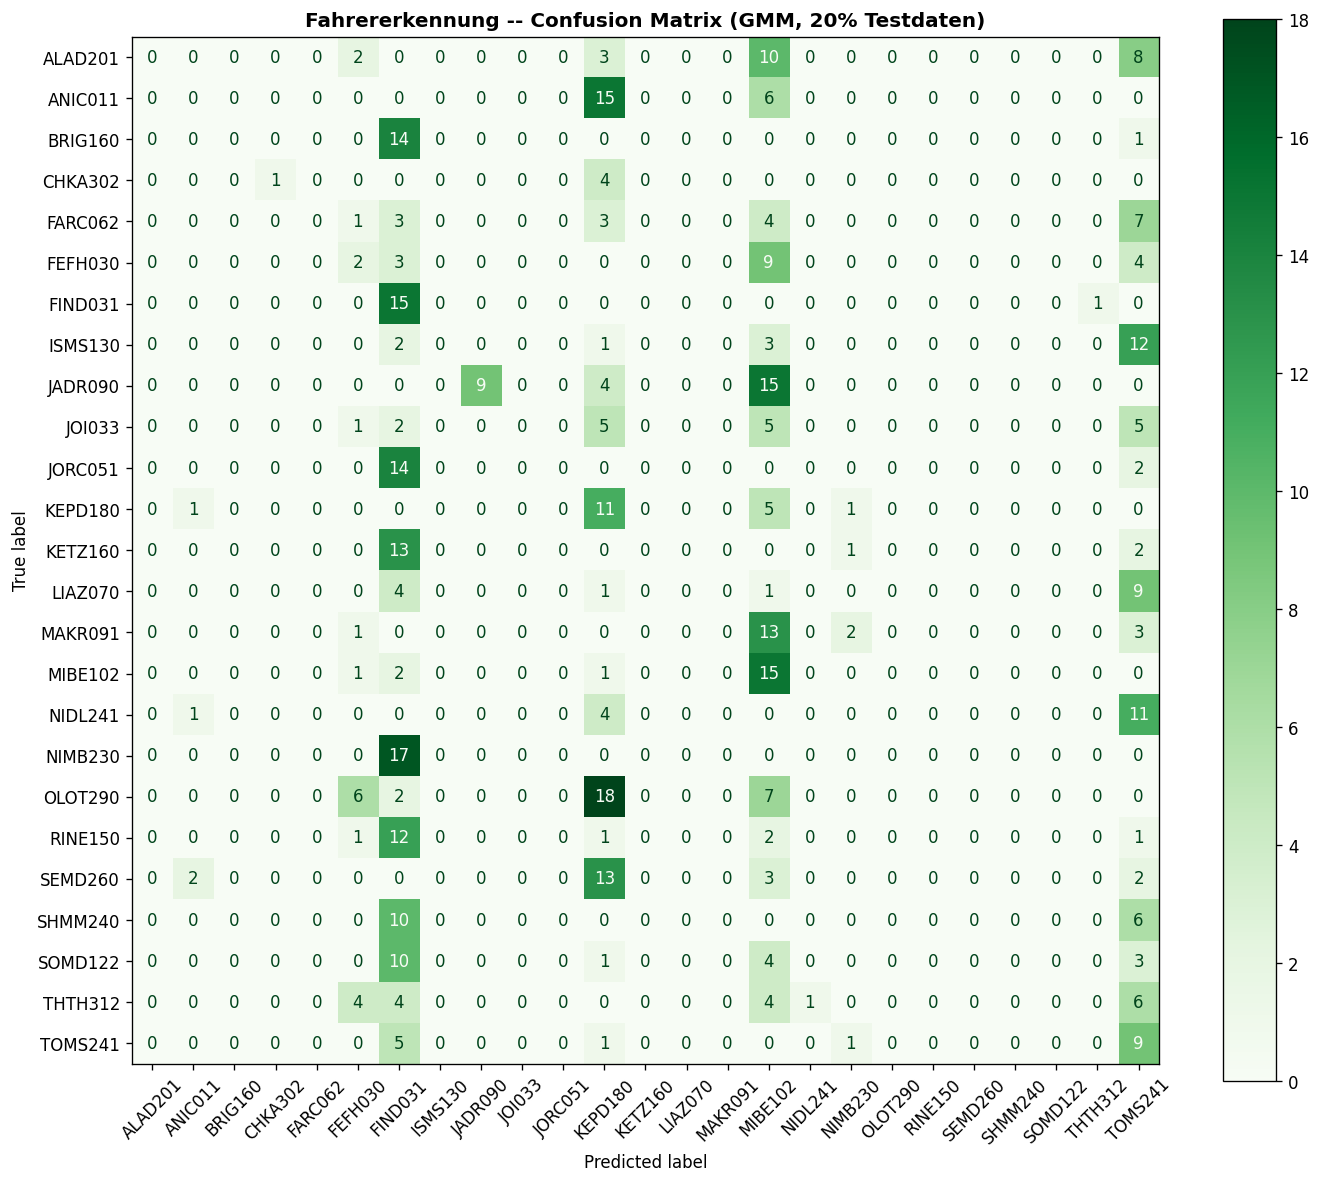

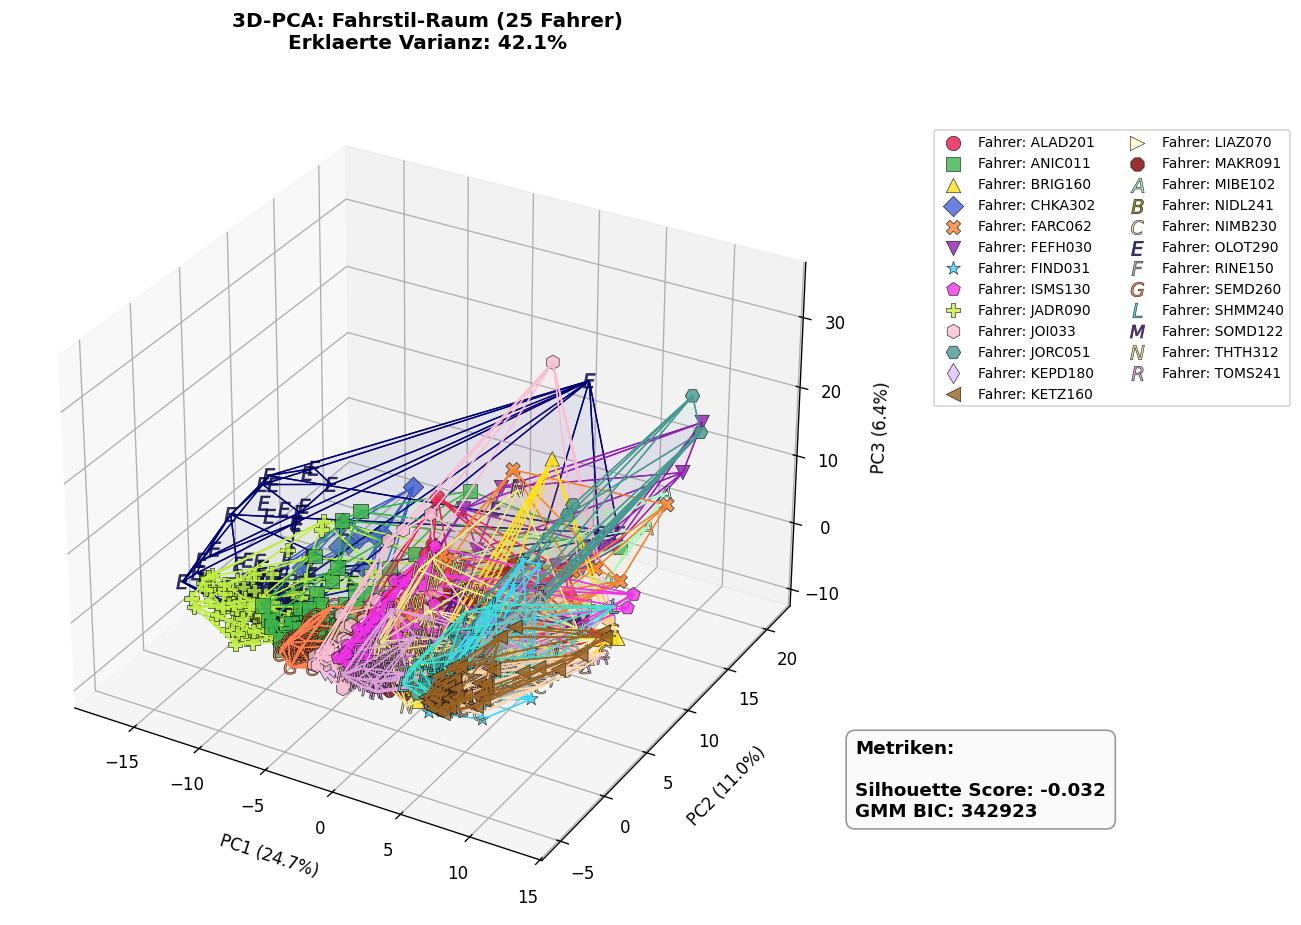

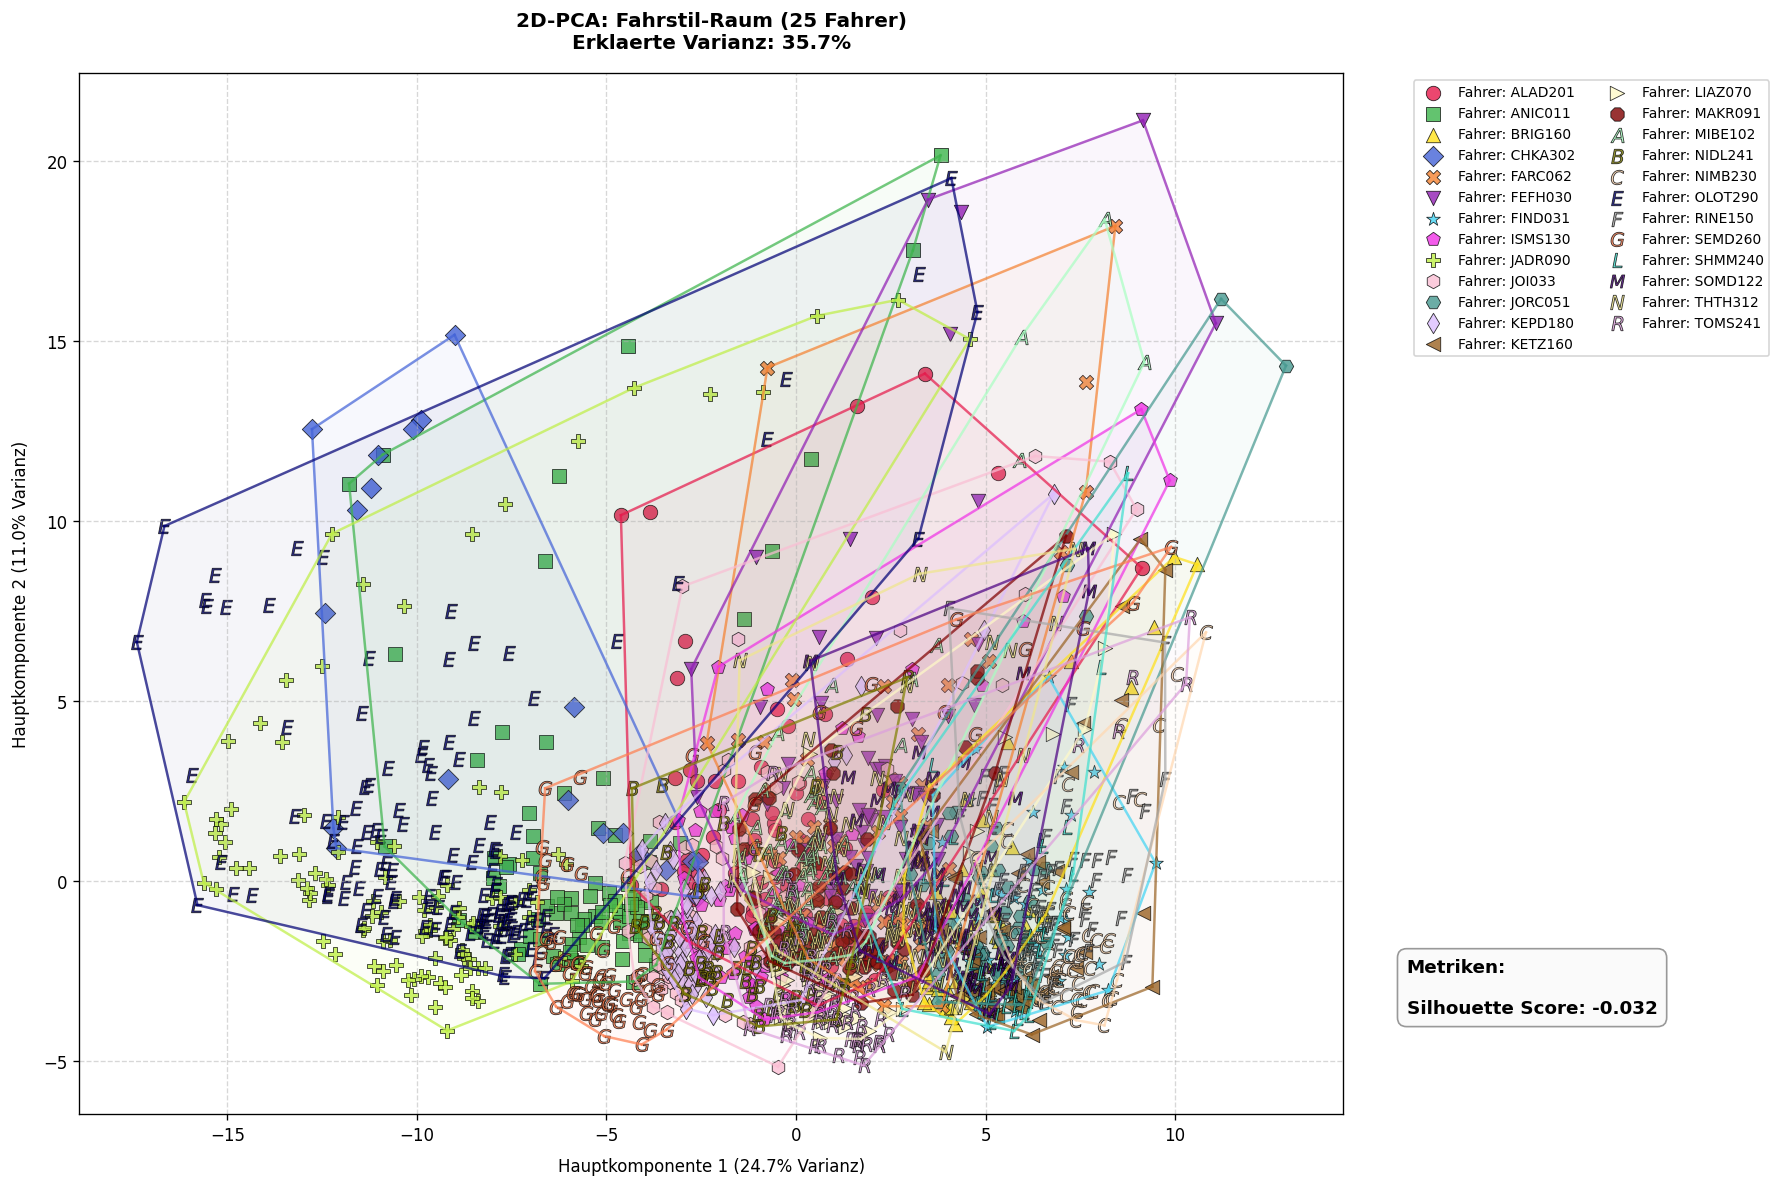


Starte Fahrer-Wachstums-Analyse (K-Means vs. GMM)...
  -> Fahrer:  2 | K-Means: 88.6% | GMM: 52.3%
  -> Fahrer:  3 | K-Means: 59.3% | GMM: 44.1%
  -> Fahrer:  4 | K-Means: 59.4% | GMM: 34.4%
  -> Fahrer:  5 | K-Means: 46.3% | GMM: 41.5%
  -> Fahrer:  6 | K-Means: 49.0% | GMM: 23.0%
  -> Fahrer:  7 | K-Means: 58.6% | GMM: 33.6%
  -> Fahrer:  8 | K-Means: 56.7% | GMM: 37.3%
  -> Fahrer:  9 | K-Means: 45.1% | GMM: 46.3%
  -> Fahrer: 10 | K-Means: 39.4% | GMM: 40.6%
  -> Fahrer: 11 | K-Means: 38.1% | GMM: 34.5%
  -> Fahrer: 12 | K-Means: 35.8% | GMM: 20.5%
  -> Fahrer: 13 | K-Means: 29.1% | GMM: 27.4%
  -> Fahrer: 14 | K-Means: 29.3% | GMM: 21.1%
  -> Fahrer: 15 | K-Means: 34.7% | GMM: 24.2%
  -> Fahrer: 16 | K-Means: 25.0% | GMM: 23.2%
  -> Fahrer: 17 | K-Means: 27.1% | GMM: 23.1%
  -> Fahrer: 18 | K-Means: 22.2% | GMM: 18.0%
  -> Fahrer: 19 | K-Means: 29.8% | GMM: 20.1%
  -> Fahrer: 20 | K-Means: 30.1% | GMM: 23.2%
  -> Fahrer: 21 | K-Means: 23.6% | GMM: 23.1%
  -> Fahrer: 22 | K-Means:

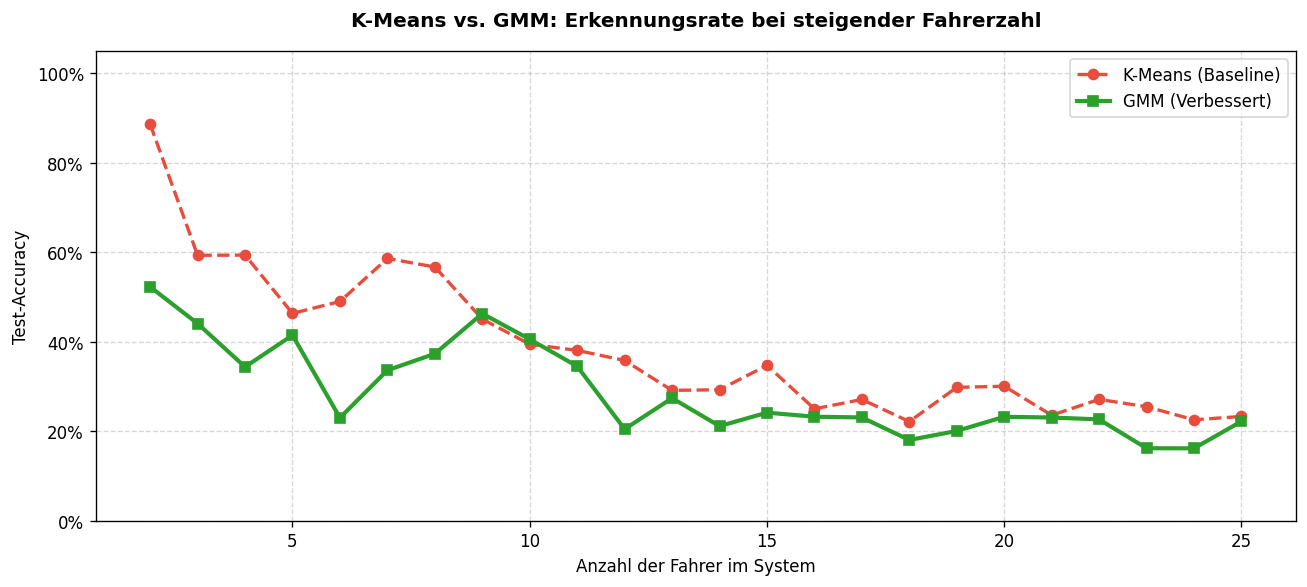


Starte Lernkurven-Analyse...
  ->  182 Segmente (10%) | K-Means: 22.6% | GMM: 9.7%
  ->  364 Segmente (20%) | K-Means: 24.2% | GMM: 12.1%
  ->  546 Segmente (30%) | K-Means: 22.0% | GMM: 8.4%
  ->  728 Segmente (40%) | K-Means: 20.7% | GMM: 9.9%
  ->  910 Segmente (50%) | K-Means: 21.5% | GMM: 6.6%
  -> 1092 Segmente (60%) | K-Means: 23.3% | GMM: 8.4%
  -> 1274 Segmente (70%) | K-Means: 23.3% | GMM: 10.3%
  -> 1456 Segmente (80%) | K-Means: 24.2% | GMM: 18.2%
  -> 1638 Segmente (90%) | K-Means: 26.8% | GMM: 16.9%
  -> 1820 Segmente (100%) | K-Means: 23.3% | GMM: 22.2%


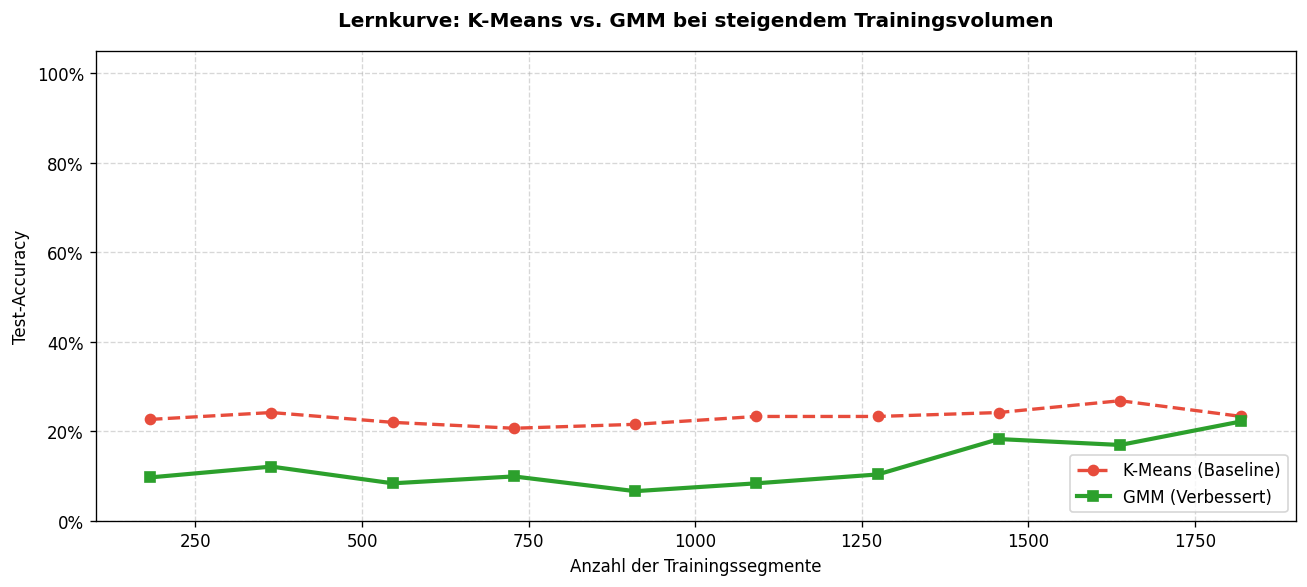

In [95]:
# =========================================================================
# VOLLSTAENDIGE PIPELINE: 80/20 Train-Test-Split mit GMM
# =========================================================================
RANDOM_SEED = 42

try:
    train_df, test_df = train_test_split(
        df_master_ml, test_size=0.2,
        random_state=RANDOM_SEED, stratify=df_master_ml['Fahrer_ID']
    )
except Exception:
    train_df, test_df = train_test_split(
        df_master_ml, test_size=0.2, random_state=RANDOM_SEED
    )

train_df = train_df.copy()
test_df  = test_df.copy()

print(f"[Daten] Training (80%): {len(train_df)} Segmente")
print(f"[Daten] Test    (20%): {len(test_df)} Segmente")

X_train = train_df[feature_cols]
X_test  = test_df[feature_cols]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

num_drivers = train_df['Fahrer_ID'].nunique()

# --- GMM Training (nur auf 80% Trainingsdaten) ---
print("\n[Training] Gaussian Mixture Model...")
gmm_final = GaussianMixture(
    n_components=num_drivers,
    covariance_type='full',
    n_init=20,
    max_iter=500,
    random_state=RANDOM_SEED
)
train_df['GMM_Cluster'] = gmm_final.fit_predict(X_train_scaled)

# Hungarian Matching
contingency_matrix = pd.crosstab(train_df['Fahrer_ID'], train_df['GMM_Cluster'])
f_idx, c_idx = linear_sum_assignment(-contingency_matrix.values)
cluster_zu_fahrer = {
    contingency_matrix.columns[c]: contingency_matrix.index[f]
    for f, c in zip(f_idx, c_idx)
}

# Inferenz auf Testdaten
test_df['Vorhergesagter_Cluster'] = gmm_final.predict(X_test_scaled)
test_df['Erkannter_Fahrer']       = test_df['Vorhergesagter_Cluster'].map(cluster_zu_fahrer)

y_true = test_df['Fahrer_ID']
y_pred = test_df['Erkannter_Fahrer']

print("\n--- Ergebnis der 20% Testdaten (GMM) ---")
print(classification_report(y_true, y_pred, zero_division=0))

sil_score = silhouette_score(X_train_scaled, train_df['Fahrer_ID'])

# --- GRAFIK 1: Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred, labels=sorted(y_true.unique()))
fig1, ax1 = plt.subplots(figsize=(12, 10), dpi=120)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=sorted(y_true.unique())
)
disp.plot(ax=ax1, cmap=plt.cm.Greens, xticks_rotation=45)
plt.title("Fahrererkennung -- Confusion Matrix (GMM, 20% Testdaten)", fontweight='bold')
plt.tight_layout()
plt.show()

# --- GRAFIK 2: 3D-Fahrstil-Raum ---
einzelne_fahrer = sorted(train_df['Fahrer_ID'].unique())
feste_farben = [
    '#e6194B','#3cb44B','#ffe119','#4363d8','#f58231',
    '#911eb4','#42d4f4','#f032e6','#bfef45','#fabed4',
    '#469990','#dcbeff','#9A6324','#fffac8','#800000',
    '#aaffc3','#808000','#ffd8b1','#000075','#a9a9a9',
    '#ff7f50','#40e0d0','#4b0082','#f0e68c','#dda0dd'
]
feste_markers = [
    'o','s','^','D','X','v','*','p','P','h','H','d','<','>','8',
    '$A$','$B$','$C$','$E$','$F$','$G$','$L$','$M$','$N$','$R$'
]
color_map  = {f: feste_farben[i % len(feste_farben)]  for i, f in enumerate(einzelne_fahrer)}
marker_map = {f: feste_markers[i % len(feste_markers)] for i, f in enumerate(einzelne_fahrer)}

pca_3d = PCA(n_components=3)
X_train_3d = pca_3d.fit_transform(X_train_scaled)

fig2 = plt.figure(figsize=(15, 9), dpi=120)
ax2  = fig2.add_subplot(111, projection='3d')
for fahrer in einzelne_fahrer:
    mask = (train_df['Fahrer_ID'] == fahrer).values
    pts  = X_train_3d[mask]
    if len(pts) == 0:
        continue
    ax2.scatter(pts[:, 0], pts[:, 1], pts[:, 2],
                color=color_map[fahrer], marker=marker_map[fahrer],
                s=75, edgecolor='k', linewidth=0.4, alpha=0.8,
                label=f"Fahrer: {fahrer}")
    if len(pts) >= 4:
        try:
            hull  = ConvexHull(pts)
            faces = [pts[simplex] for simplex in hull.simplices]
            poly  = Poly3DCollection(
                faces, facecolors=color_map[fahrer],
                edgecolors=color_map[fahrer], linewidths=0.8, alpha=0.03
            )
            ax2.add_collection3d(poly)
        except Exception:
            pass

var3d = pca_3d.explained_variance_ratio_
ax2.set_title(
    f"3D-PCA: Fahrstil-Raum ({len(einzelne_fahrer)} Fahrer)\n"
    f"Erklaerte Varianz: {sum(var3d):.1%}",
    fontweight='bold', pad=20
)
ax2.set_xlabel(f"PC1 ({var3d[0]:.1%})", labelpad=10)
ax2.set_ylabel(f"PC2 ({var3d[1]:.1%})", labelpad=10)
ax2.set_zlabel(f"PC3 ({var3d[2]:.1%})", labelpad=10)
ax2.legend(loc='upper left', bbox_to_anchor=(1.1, 0.95), ncol=2, fontsize='small')
fig2.text(
    0.75, 0.20,
    f"Metriken:\n\nSilhouette Score: {sil_score:.3f}\nGMM BIC: {gmm_final.bic(X_train_scaled):.0f}",
    fontsize=11, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#f9f9f9', edgecolor='gray', alpha=0.8)
)
plt.show()

# --- GRAFIK 3: 2D Convex-Hull-Plot ---
pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train_scaled)
var2d = pca_2d.explained_variance_ratio_

fig3, ax3 = plt.subplots(figsize=(15, 10), dpi=120)
for fahrer in einzelne_fahrer:
    mask = (train_df['Fahrer_ID'] == fahrer).values
    pts  = X_train_2d[mask]
    if len(pts) == 0:
        continue
    ax3.scatter(pts[:, 0], pts[:, 1],
                color=color_map[fahrer], marker=marker_map[fahrer],
                s=75, edgecolor='k', linewidth=0.5, alpha=0.8,
                label=f"Fahrer: {fahrer}")
    if len(pts) >= 3:
        try:
            hull = ConvexHull(pts)
            for simplex in hull.simplices:
                ax3.plot(pts[simplex, 0], pts[simplex, 1],
                         color=color_map[fahrer], linestyle='-', linewidth=1.5, alpha=0.7)
            ax3.fill(pts[hull.vertices, 0], pts[hull.vertices, 1],
                     color=color_map[fahrer], alpha=0.04)
        except Exception:
            pass

ax3.set_title(
    f"2D-PCA: Fahrstil-Raum ({len(einzelne_fahrer)} Fahrer)\n"
    f"Erklaerte Varianz: {sum(var2d):.1%}",
    fontweight='bold', pad=15
)
ax3.set_xlabel(f"Hauptkomponente 1 ({var2d[0]:.1%} Varianz)", labelpad=8)
ax3.set_ylabel(f"Hauptkomponente 2 ({var2d[1]:.1%} Varianz)", labelpad=8)
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='upper left', bbox_to_anchor=(1.05, 1), ncol=2, fontsize='small')
ax3.text(
    1.05, 0.15,
    f"Metriken:\n\nSilhouette Score: {sil_score:.3f}",
    transform=ax3.transAxes, fontsize=11, fontweight='bold',
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#f9f9f9', edgecolor='gray', alpha=0.8)
)
plt.tight_layout()
plt.show()

# =========================================================================
# WACHSTUMS-ANALYSE: K-Means vs. GMM nach Fahrerzahl
# =========================================================================
print("\nStarte Fahrer-Wachstums-Analyse (K-Means vs. GMM)...")
n_list, acc_km_list, acc_gmm_list = [], [], []

for n in range(2, num_drivers + 1):
    fahrer_sub = einzelne_fahrer[:n]
    df_sub = df_master_ml[df_master_ml['Fahrer_ID'].isin(fahrer_sub)].copy()
    try:
        tr, te = train_test_split(
            df_sub, test_size=0.2, random_state=RANDOM_SEED,
            stratify=df_sub['Fahrer_ID']
        )
    except Exception:
        tr, te = train_test_split(df_sub, test_size=0.2, random_state=RANDOM_SEED)
    tr = tr.copy()
    te = te.copy()
    sc = StandardScaler()
    X_tr = sc.fit_transform(tr[feature_cols])
    X_te = sc.transform(te[feature_cols])

    # K-Means
    km = KMeans(n_clusters=n, random_state=RANDOM_SEED, n_init=10)
    tr['km_cl'] = km.fit_predict(X_tr)
    cm_km = pd.crosstab(tr['Fahrer_ID'], tr['km_cl'])
    fi, ci = linear_sum_assignment(-cm_km.values)
    mp_km = {cm_km.columns[c]: cm_km.index[f] for f, c in zip(fi, ci)}
    te['km_pred'] = pd.Series(km.predict(X_te), index=te.index).map(mp_km)
    acc_km = accuracy_score(te['Fahrer_ID'], te['km_pred'])

    # GMM
    gm = GaussianMixture(
        n_components=n, covariance_type='full',
        n_init=5, random_state=RANDOM_SEED
    )
    tr['gm_cl'] = gm.fit_predict(X_tr)
    cm_gm = pd.crosstab(tr['Fahrer_ID'], tr['gm_cl'])
    fi, ci = linear_sum_assignment(-cm_gm.values)
    mp_gm = {cm_gm.columns[c]: cm_gm.index[f] for f, c in zip(fi, ci)}
    te['gm_pred'] = pd.Series(gm.predict(X_te), index=te.index).map(mp_gm)
    acc_gm = accuracy_score(te['Fahrer_ID'], te['gm_pred'])

    n_list.append(n)
    acc_km_list.append(acc_km)
    acc_gmm_list.append(acc_gm)
    print(f"  -> Fahrer: {n:2d} | K-Means: {acc_km:.1%} | GMM: {acc_gm:.1%}")

plt.figure(figsize=(11, 5), dpi=120)
plt.plot(n_list, acc_km_list,  marker='o', linestyle='--', color='#e74c3c',
         linewidth=2, label="K-Means (Baseline)")
plt.plot(n_list, acc_gmm_list, marker='s', linestyle='-',  color='#2ca02c',
         linewidth=2.5, label="GMM (Verbessert)")
plt.title("K-Means vs. GMM: Erkennungsrate bei steigender Fahrerzahl",
          fontweight='bold', pad=15)
plt.xlabel("Anzahl der Fahrer im System")
plt.ylabel("Test-Accuracy")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================================
# LERNKURVE: Genauigkeit bei steigendem Trainingsvolumen
# =========================================================================
print("\nStarte Lernkurven-Analyse...")
try:
    df_train_full, df_test_fixed = train_test_split(
        df_master_ml, test_size=0.2, random_state=RANDOM_SEED,
        stratify=df_master_ml['Fahrer_ID']
    )
except Exception:
    df_train_full, df_test_fixed = train_test_split(
        df_master_ml, test_size=0.2, random_state=RANDOM_SEED
    )

df_test_fixed = df_test_fixed.copy()
seg_liste, acc_km_lk, acc_gmm_lk = [], [], []

for prozent in np.arange(0.1, 1.1, 0.1):
    if prozent < 1.0:
        try:
            df_tr_sub, _ = train_test_split(
                df_train_full, train_size=prozent, random_state=RANDOM_SEED,
                stratify=df_train_full['Fahrer_ID']
            )
        except Exception:
            df_tr_sub, _ = train_test_split(
                df_train_full, train_size=prozent, random_state=RANDOM_SEED
            )
    else:
        df_tr_sub = df_train_full.copy()

    anzahl = len(df_tr_sub)
    if anzahl < num_drivers:
        print(f"  -> {anzahl:4d} Segmente: zu wenig Daten, ueberspringe.")
        continue

    df_tr_sub = df_tr_sub.copy()
    sc_lk = StandardScaler()
    X_tr_s = sc_lk.fit_transform(df_tr_sub[feature_cols])
    X_te_s = sc_lk.transform(df_test_fixed[feature_cols])

    # K-Means
    km_lk = KMeans(n_clusters=num_drivers, random_state=RANDOM_SEED, n_init=10)
    df_tr_sub['Cluster_ID'] = km_lk.fit_predict(X_tr_s)
    c_mat = pd.crosstab(df_tr_sub['Fahrer_ID'], df_tr_sub['Cluster_ID'])
    fi, ci = linear_sum_assignment(-c_mat.values)
    mp_km_lk = {c_mat.columns[c]: c_mat.index[f] for f, c in zip(fi, ci)}
    df_test_fixed['Pred_km'] = pd.Series(km_lk.predict(X_te_s), index=df_test_fixed.index).map(mp_km_lk)
    acc_km_lk_val = accuracy_score(df_test_fixed['Fahrer_ID'], df_test_fixed['Pred_km'])

    # GMM
    gm_lk = GaussianMixture(
        n_components=num_drivers, covariance_type='full',
        n_init=5, random_state=RANDOM_SEED
    )
    df_tr_sub['GMM_Cluster_ID'] = gm_lk.fit_predict(X_tr_s)
    g_mat = pd.crosstab(df_tr_sub['Fahrer_ID'], df_tr_sub['GMM_Cluster_ID'])
    fi, ci = linear_sum_assignment(-g_mat.values)
    mp_gm_lk = {g_mat.columns[c]: g_mat.index[f] for f, c in zip(fi, ci)}
    df_test_fixed['Pred_gm'] = pd.Series(gm_lk.predict(X_te_s), index=df_test_fixed.index).map(mp_gm_lk)
    acc_gmm_lk_val = accuracy_score(df_test_fixed['Fahrer_ID'], df_test_fixed['Pred_gm'])

    seg_liste.append(anzahl)
    acc_km_lk.append(acc_km_lk_val)
    acc_gmm_lk.append(acc_gmm_lk_val)
    print(f"  -> {anzahl:4d} Segmente ({prozent:.0%}) | K-Means: {acc_km_lk_val:.1%} | GMM: {acc_gmm_lk_val:.1%}")

plt.figure(figsize=(11, 5), dpi=120)
plt.plot(seg_liste, acc_km_lk,  marker='o', linestyle='--', color='#e74c3c',
         linewidth=2, label="K-Means (Baseline)")
plt.plot(seg_liste, acc_gmm_lk, marker='s', linestyle='-',  color='#2ca02c',
         linewidth=2.5, label="GMM (Verbessert)")
plt.title("Lernkurve: K-Means vs. GMM bei steigendem Trainingsvolumen",
          fontweight='bold', pad=15)
plt.xlabel("Anzahl der Trainingssegmente")
plt.ylabel("Test-Accuracy")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()